In [ ]:
# 2025.11.03. 월 7교시
# 1. 결정 트리 (Decision Tree)  
# 결정 트리는 머신러닝 분류(Classification) 알고리즘 중 가장 직관적이고 이해하기 쉬운 모델 중 하나입니다. 
# 데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리(Tree) 기반의 분류 규칙을 만드는 알고리즘으로,
# '스무고개' 게임과 유사한 방식으로 동작합니다

# 1.1. 결정 트리란?
# 결정 트리는 데이터의 특징(feature)을 기반으로 질문을 던져가며 정답을 찾아가는 모델입니다.
# 각 질문은 '노드(Node)'가 되며, 이진 노드 "규칙"으로 나누는.. "root node" 도 규칙이 있다
# root node : 하위 노드 중에 불순도가 많은 것을 root node 로 하는 거다. 1st child 가지고 root 만드는 거고, 그 규칙이 생긴다 
# 1st child 를 보고 지니, 엔트로피 계수를 root node 로 구한다
# root node는 전체 데이터 가지고 생성한다 => 그래서 데이터가 많으면 처리가 만만치 않다
# 질문의 결과에 따라 다음 질문으로 이동하는 '가지(Branch)'를 통해 
# 최종 결론인 '잎 노드(Leaf Node)'에 도달합니다.

In [ ]:
• 루트 노드 (Root Node): 트리의 시작점으로, 전체 데이터를 포함합니다.
• 규칙 노드 (Decision Node): 데이터를 특정 기준에 따라 나누는 중간 노드입니다.
• 리프 노드 (Leaf Node): 최종적인 분류 결과가 결정되는 노드입니다.
• 서브 트리 (Sub-tree): 하나의 규칙 노드와 그에 속한 자식 노드들로 구성된 작은 트리입니다. Branch

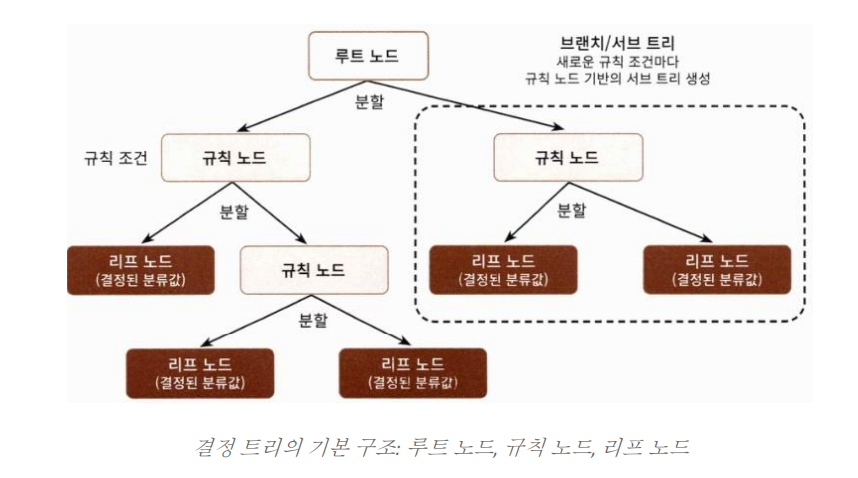

In [ ]:
# 결정 트리의 핵심은 '어떻게 데이터를 가장 잘 나눌 것인가?'에 있습니다. 
# 데이터를 나눌 때, 각 영역의 데이터가 "한 가지 종류로만" 구성되도록 만드는 것이 목표입니다. 
# 이를 '불순도(Impurity)'를 낮추는 방향으로 학습한다고 표현합니다.

In [ ]:
# 데이터의 불순도를 측정하는 대표적인 지표는 지니 계수(Gini Index)와 엔트로피(Entropy)가 있습니다.
# • 지니 계수: 0 부터 0.5 값을 가지며, 0 이면 데이터가 완벽하게 한 종류로만 구성된 순수한 상태를 의미합니다. 
#   ScikitLearn 의 DecisionTreeClassifier 는 기본적으로 지니 계수를 사용합니다. => why 속도가 빠름
# • 엔트로피: 0 ~ 1사이 데이터의 혼잡도를 나타내는 지표로, 엔트로피가 높을수록 데이터가 여러 종류로 섞여 있음을 의미합니다.
# 결정 트리는 이러한 지표를 사용하여 정보 이득(Information Gain: 위, 아래 2개가 있어야 함, 정보량(분산 - 많이 섞여 있ㄴ은거))이 
# 최대가 되거나, 지니 계수 또는 엔트로피가 최소가 되는 방향으로 데이터를 분할해 나갑니다


In [ ]:
# Tree 의 목표 : 순도가 높은 영역(Leaf Node)를 생성하는 거다
#                (순도가 높다 : 순수하다) 불순도를 감소 시키는 학습를 하는 거다

##### 불순도 측정 지표
1. 지니 계수(인덱스) 
$$ \text{Gini}(D) = 1 - \sum_{i=1}^{n} p_i^2 $$
2. 엔트로피 계수
$$ \text{Entropy}(D) = - \sum_{i=1}^{n} p_i \log_2 p_i $$

- D : 데이터 집합
- p_i : 클래스 i에 속할 확률 (즉, 클래스 i의 비율)
- n : 클래스의 총 개수
- 엔트로피 : 로그 밑은 2를 사용합니다 (정보 이론에서 일반적)


In [ ]:
# 오늘은 여기까지~ : 내일부터 1.2 parameter

In [ ]:
# 2025.11.04.화 1교시
# Tree 계열 파라미터 외워라!
# HyperParamater : 새로운 데이터 예측 성능 항상이 "일반화"고 이걸 하기 위한 것. 복잡도를 뭉갠다

# 1.2. 결정 트리의 주요 파라미터
# Scikit-Learn 의 DecisionTreeClassifier 는 다양한 "하이퍼파라미터"를 제공하여 모델의 "복잡도를 제어(=>일반화한다)"하고 "과적합을 방지"할 수 있습니다. 
# 주요 파라미터는 다음과 같습니다.
# 이중 max_depth ~ max_leaf_nodes : 과적합 방지용
# root node - 불순도가 max 인 노드
# "samples" == 데이터의 수

파라미터 | 설명 : Tree계열은 무조건 끝까지 내려가면 '과적합'이 나온다규!!!! * 많이 쓰는 놈
---------|---------------------
 criterion | 분할 품질을 측정하는 기능 ('gini' 또는 'entropy').  <span style="color:yellow">기본값은 'gini'</span>
splitter |각 노드에서 분할을 선택하는 전략 ('best' 또는 'random'). 기본값은 'best'
<span style="color:#FF7708">max_depth*</span> |트리의 최대 깊이. 이 값을 작게 설정하면 모델이 (복잡도가) 단순해져 과적합을 방지할 수 있다. (가지치기)
<span style="color:#FF7708">min_samples_split*</span> | 노드를 분할하기 위한 최소 샘플 수. 이 값보다 샘플 수가 적으면 더 이상 분할하지 않음. 과적합 제어에 사용
<span style="color:#FF7708">min_samples_leaf</span> |리프 노드가 되기 위한 최소 샘플 수. 이 값보다 샘플 수가 적은 리프 노드는 만들어지지 않음. 과적합 제어에 사용
<span style="color:#FF7708">max_features*</span> | 최적의 분할을 찾을 때 고려할 "피처(컬럼)"의 최대 개수. <br>('auto', 'sqrt(제곱근)', 'log2'(피쳐 수가 많을때), 정수(갯수), 실수(는 %다)) <br> 특히 <span style="color:red">RandomForest</span>에서 막강
<span style="color:#FF7708">max_leaf_nodes</span> | 리프 노드의 최대 개수.

In [ ]:
# 1.3. 결정 트리 시각화: Graphviz => old 하고 설치/제어 복잡해서 수업도 안해~ 특히 VC++ 도 설치해야해.
# 그래서 다른 2가지 방식 알려줄꾸마
# 시각화 이유 - 과적합 제어와 feataure의 중요도, 고객 프레젠테이션시 용이ㅇ


##### 시각화 Lib 3종 
1. plot_tree() (sklearn 내장) with matplotlib 
2. dtreeviz() - 가장 예쁨 설치해야 함. 함수, 분포 표시해 줌 => 해석이 쉬워 짐 # 설치: pip install dtreeviz <- 요거로 코딩할 꺼임
3. Graphvis() - export_graphviz - 전통적 방법

In [ ]:
# 2. 앙상블 학습(Ensemble Learning) - 7교시
# 2.1. 앙상블 학습의 개념
# 앙상블 학습은 여러 개의 분류기(Classifier : 모델)를 생성하고, 그 예측을 결합함으로써 단일 분류기(D.T)보다 더 높은 성능을 내는 방법입니다. 
# '집단 지성'의 원리(보팅)와 유사하며, 정형 데이터(테이블 형태) 분류에서 매우 뛰어난 성능을 보여줍니다.
# 앙상블 학습은 크게 배깅(Bagging), 부스팅(Boosting) 나누고 보팅(Voting)은 배깅에 포함되는 거다

# 모델과 알고리즘은 다르지만 교재에서는 같이 쓴다.. 맘에 안드신다고~

In [ ]:
# 2.2. 보팅(Voting)
# 보팅은 "서로 다른 모델"에서 (ex: DT, RF, LR)을 가진 여러 분류기가 같은 데이터셋을 학습하고, 투표를 통해 최종 예측을 결정하는 방식입니다.
# • 하드 보팅 (Hard Voting)  : 다수결 원칙과 같습니다. 각 분류기가 예측한 클래스 중 가장 많이 나온 클래스를 최종 결과로 선택합니다.
# • 소프트 보팅 (Soft Voting): 각 분류기가 예측한 클래스별 '확률'을 평균 내어, 가장 높은 확률을 가진 클래스를 최종 결과로 선택합니다. 
#                              일반적으로 하드 보팅보다 성능이 더 좋습니다. 그래서 많이 써! 대신 연산속도는 좀 느림

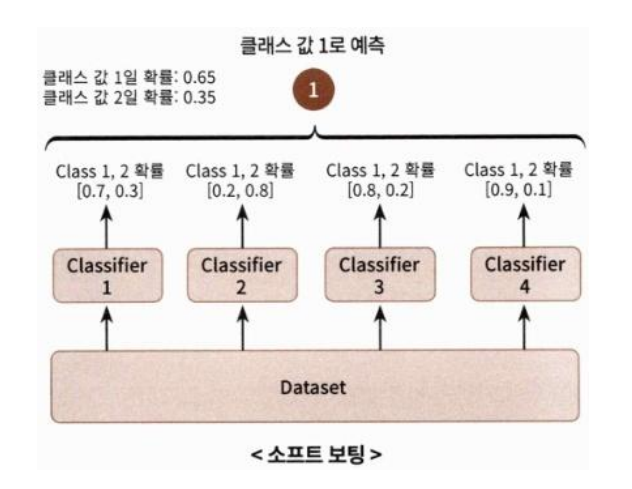

In [ ]:
# KNN 은  모델은 아니다. 왜 학습을 안하니까 하지만 나중에 DBSCAN 군집할때 나옴
# 보팅 실습 코딩은 안해~

In [ ]:
# 2.3. 배깅 (Bagging)과 랜덤 포레스트(Random Forest : RF)
# 배깅과 부스팅이 합쳐진게 신경망이야 그래서 배깅은 좀 봐 둬야 해
# 배깅 (Bagging)
# 배깅(Bagging, Bootstrap Aggregating 의 약자)은 "같은 유형의 모델(EX) RF : DT를 여러개 사용함)"을 사용하지만, 
# [원본 데이터셋에서 중복을 허용하여 "샘플링한(부트스트래핑)" 여러 개의 서브 데이터셋을 만들어 각 분류기를] 학습시키는 방식입니다. 
# 최종 예측은 보팅을 통해 결정됩니다.


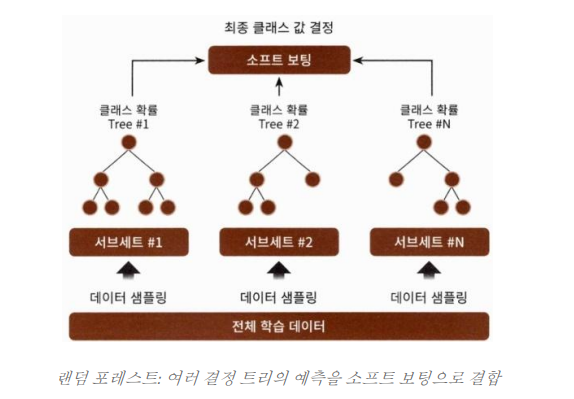

In [2]:
# 랜덤 포레스트 (Random Forest) : 예측 확률로 예측값을 뽑아내고, 소프트 보팅
# 랜덤 포레스트는 배깅의 대표적인 알고리즘으로, 기반 모델로 결정 트리(DT)를 사용합니다. 
# 여러 개의 결정 트리가 모여 숲(Forest)을 이룬다는 의미에서 이름 붙여졌습니다. 
# 랜덤 포레스트는 배깅 방식에 더해, 각 트리를 학습할 때 전체 피처 중 일부만 무작위로 선택하여 사용하는 특징이 있습니다. 
# 이를 통해 각 트리의 상관관계를 줄여 모델의 다양성을 높이고, 결과적으로 더 안정적이고 높은 성능을 이끌어냅니다.

# 일부데이터를 샘플링, 여러개의 DT를 사용, 예측확률(_proba)로 예측한다

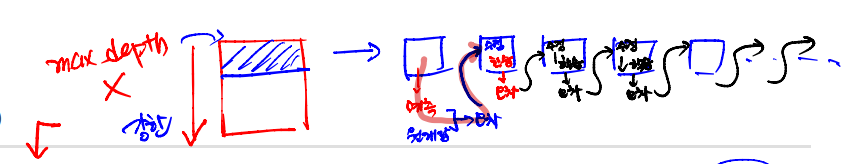

In [2]:
# 2025.11.05.수.2교시
# 2.4. 부스팅 (Boosting) : 강한 학습기 = max_depth를 안 주면 끝~까지 분할하는 거다
# 부스팅은 여러 개의 "약한 학습기(weak learner)"를 "순차적"으로 학습-예측하면서, 
# 이전 학습기가 잘못 예측한 데이터에 가중치를 부여하여 다음 학습기가 더 잘 학습하도록 만드는 방식. 
# 이 과정을 반복하여 점차 강력한 최종 모델을 만들어냄. ==> 병렬처리 안됨
# 대표적인 부스팅 알고리즘으로는 AdaBoost(Adaptive Boosting 에이다부스트)와 그래디언트 부스팅(Gradient Boosting 경사/기울기(오차): GB) 계열이 있다
# 요즘은 AdaBoosting 보다 GB를 많이 사용한다. 신경망에서도...

# 쿠다툴킷설치해야 한다. XGBM, LightGBM 할때

In [3]:
# 3. 부스팅 알고리즘: GBM, XGBoost(진짜 많이쓰임), LightGBM
# 그래디언트 부스팅 GB는 부스팅의 한 종류로, 가중치(규제 )를 업데이트할 때 경사 하강법(Gradient Descent : DL에서의 역전파)을 이용하는 것이 특징.
# 즉, 이전 모델의 예측 오류(잔차, residual)를 다음 모델이 학습하도록 하여 점진적으로 오류를 줄여나갑니다. 
# 이 GB을 기반으로 한 GBM, XGBoost(거의 성능높고), LightGBM(야야악간 성능이 떨어지만 속도는 ↑)은 
# 현재 캐글(Kaggle)과 같은 데이터 분석 대회에서 가장 많이 사용되는 강력한 알고리즘들. => 특히 XGBoost, 캐글은 대회라 데이터량이 많지 않아서임

# 딥러닝 요건 : 1. Data량이 많아야 한다

In [ ]:
# 3.1. GBM (Gradient Boosting Machine)
# GBM 은 그래디언트 부스팅의 기본적인 구현체입니다. Scikit-Learn 에서는 GradientBoostingClassifier 클래스를 제공.
# python 기반의 GBM도 있다, 어떤걸 사용하느냐에 따라 HyperParam. 이 다르다

# GBM 의 주요 하이퍼파라미터는 다음과 같습니다
# • loss(): 경사 하강법(GD)에 사용할 비용 함수. => 오차를 구하는 함수
# • learning_rate: 학습률(HyperParameter!!! loss 나오면 learning_rate나온다). 
#                  적당한 값을 부여해야 한다. search해야 해 deep learning 가면 0.000001 까지도 준다
#                  너무 크면 과적합뿐만 아니라 발산,ㅇ
#                  너무 작으면 학습이 느려짐. 보통 0.0001 ~ 0.1 사이의 값을 사용 (울 쌤 기준)
# • n_estimators: 생성할 약한 학습기(트리)의 개수. 많을수록 성능이 좋아질 수도 있지만(보장 안됨), 시간도 오래 걸리고 과적합의 위험이 있음.
# • subsample: 각 트리를 학습할 때 사용할 데이터 샘플의 비율. (배깅과 유사 ex) 0.4)

# learning_rate 와 n_estimators 는 서로 트레이드오프 관계에 있습니다. (성능이 아니라 속도)
# 학습률을 낮추면 더 많은 트리가 필요?, (학습률 ↓ (꼼꼼하게 하겠다는 뜻) => 학습시간↑, 성능 ↑ 수 있다 - OverFitting 가능성도 올라가)
# 학습률을 높이면 더 적은 트리가 필요? (학습률 ↑ (대충 하겠다는 뜻) => 학습시간↓, 성능 ↓ 수 있다 - UnderFitting될 수도 있다 => 일반화성능이 떨어짐)

In [1]:
# 3.2. XGBoost (eXtra Gradient Boost) : 핵심은 규제!!!! 'C' 언어로 만들어짐
# XGBoost 는 GBM 을 기반으로 하지만, 병렬 처리(CPU+GPU), "규제"(Regularization: 일반화 성능을 높이는게 목적 - 복잡도를 뭉겐다), 
# 가지치기(Tree Pruning) 등의 기능을 추가하여 성능과 속도(병렬 처리 때문)를 크게 개선한 알고리즘? 모델이다. 
# GBM(여기에 규제가 없으니) 보다 빠르면서도 과적합 방지에 더 효과적입니다.

# XGBoost 설치
# PIP 는 항상 최신버전을 유지해라!!! conda-forge 채널을 사용하자
# 교재 : conda install -c anaconda py-xgboost : 요즘 그냥 xgboost, 
# conda install -c conda-forge xgboot
# pip install xgboost @ python channel에서 하는 거임 요고했음

# conda remove --name ml_dev01 --all # 콘다에서 가상환경 삭제하는 명령어임

# pip 를 쓰거나 conda install 가능하면 둘 중 하나만 사용해라! 
# 어쩌다가 conda-forge 를 사용해야 하면 (최~~신버전인 경우) 제외


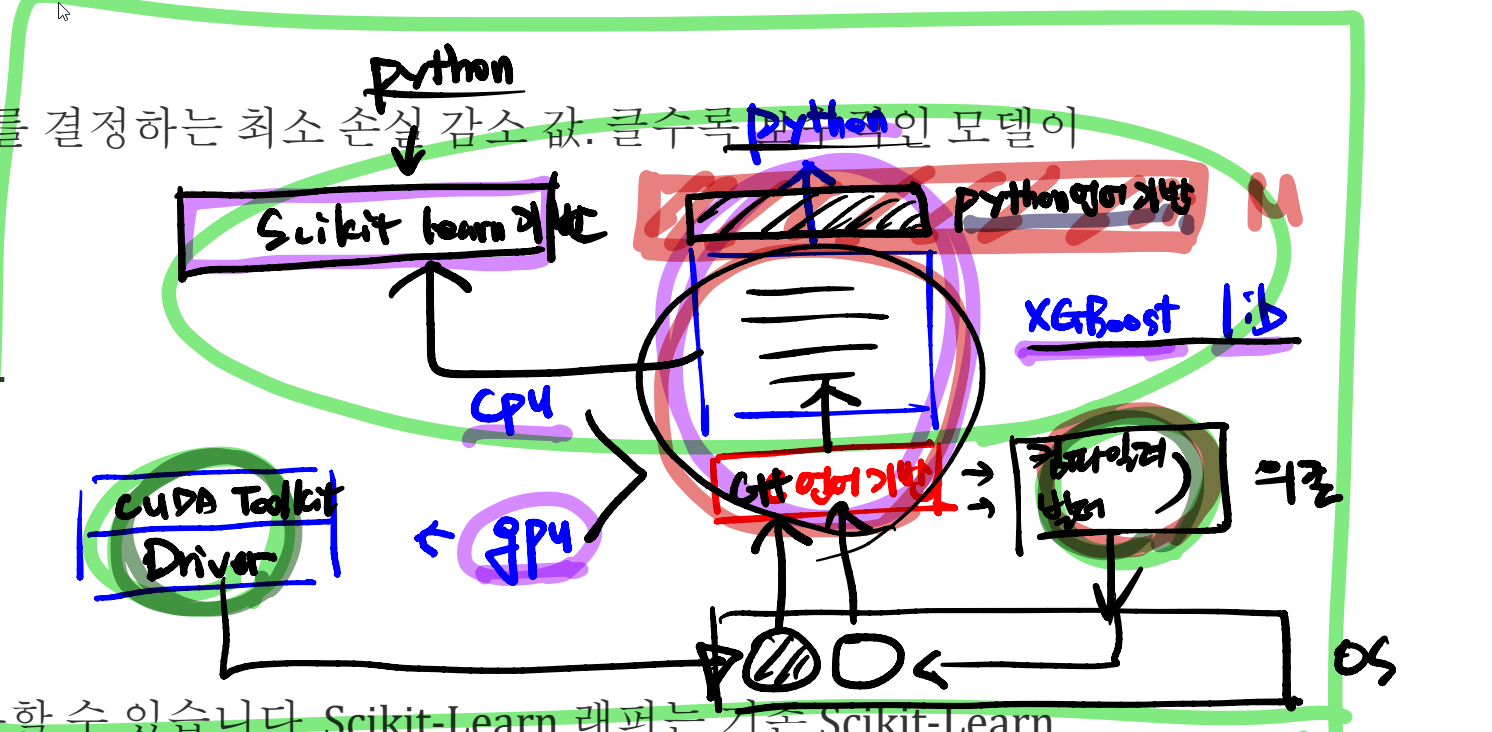

In [1]:
# XGBoost 는 GBM 의 파라미터 외에 자체적인 파라미터를 다수 포함합니다.
# • eta(learning_rate): 학습률. eta : python기준, learn_rate = sklearn 기반
# • num_boost_round(n_estimators): 부스팅 반복 횟수. tree 갯수
# • gamma(min_split_loss): 리프 노드를 추가적으로 분할할지를 결정하는 최소 손실 감소 값. 클수록 보수적인 모델이 됩니다.
# • max_depth: 트리의 최대 깊이.
# • subsample: 각 트리를 학습할 때 사용할 데이터 "샘플의 비율".
# • colsample_bytree** : 각 트리를 학습할 때 사용할 "피처의 비율".
# • lambda(reg_lambda)***: L2 규제(Regularization) 파라미터.
# • alpha(reg_alpha)***: L1 규제 파라미터.

# XGBoost 는 파이썬 래퍼(wrapper 기반)와 Scikit-Learn(괄호안에 있는) 래퍼 두 가지 방식으로 사용할 수 있습니다. 
# Scikit-Learn 래퍼는 기존 Scikit-Learn 프레임워크와 호환되어 사용이 편리합니다. 
# 특히 조기 중단(Early Stopping) 기능은 매우 유용합니다. => Boosting이기 때문에 중간에 멈출 수 있다. 조기 종료 가능
# 조기 중단은 검증 데이터셋(evaluation set)의 성능이 일정 반복 횟수(early_stopping_rounds) 동안 개선되지 않으면 
# 학습을 자동으로 멈추는 기능으로, 불필요한 학습을 막고 과적합을 방지합니다.
# XGBoost = 학습 데이터와 검증 데이터 둘 다 넣어줘야 한다


In [ ]:
# 2025.11.06.목 ---------------------------------------------------------------------------------------------------- #
# 3.3. LightGBM : XGBoost 를 더 많이 쓸 껄? 둘 다 해봐야지 학생은~ MicroSoft에서 개발
# LightGBM 은 XGBoost 와 함께 현재 가장 주목받는 그래디언트 부스팅 모델!
# XGBoost(? GBM) 보다 학습 시간이 훨씬 빠르고 메모리 사용량도 적으면서, 예측 성능은 유사하거나 더 높은 경우가 많다? 쌤은 좀 낮은 편.
# 기존의 대부분 Tree 기반 모델이 트리의 깊이를 우선으로 하는 균형 트리 분할(Level-wise) 방식을 사용하는 것과 대조적입니다.


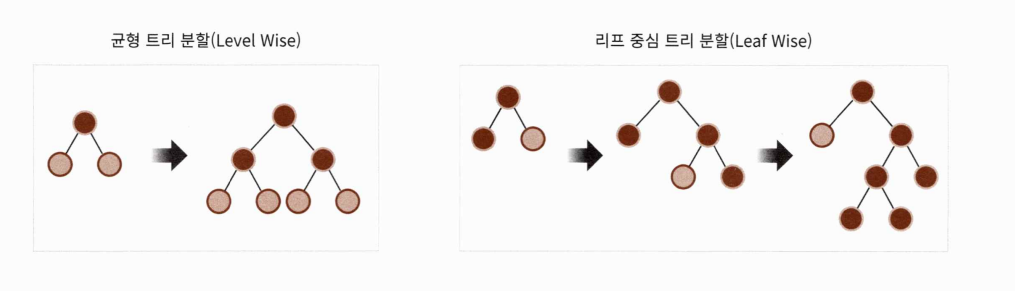
- LightGBM 은 max_depth를 좀 깊게 줘야 한다 (크게 줘라) - 11.07.금 6교시에 추가함 

In [ ]:
# * c:\big20\lib 폴더 만들고 VC_redist.x64.exe 옮겨놔라. 딥러닝에서 사용할것이당

# LightGBM 설치
# Conda 사용 시 : 우선 ml_dev 로 이동 후 설치하는데 아래처럼 설치하면 이 VM만 설치됨!!!
# conda activate ml_dev @ conda prompt
# conda install -c conda-forge lightgbm => 패키지로 설치됨 그래서 numpy-2.3.4 로 업그레이드 된다. 버전 충돌 날 수도!!!
# [실습] LightGBM 적용
# LightGBM 도 XGBoost 와 마찬가지로 조기 중단 기능을 지원. 유방암 데이터셋에 적용해 보겠다~.

In [ ]:
# 4. 베이지안 최적화 기반 HyperOpt
# 4.1. 하이퍼파라미터 튜닝의 어려움
# GridSearchCV(Best Param 찾기) 는 지정된 모든 하이퍼파라미터 조합을 순차적으로 시도하기 때문에 매우 직관적이지만,=> 장점 
# 탐색 공간이 넓어지면 시간이 기하급수적으로 증가하는 큰 단점 있음! 
# ex: 5개의 파라미터를 5개씩 값을 테스트하면 5^5=3125번 반복, 3125개의 모델(램 문제 발생할 수 있지?)

# 4.2. 베이지안 최적화와 HyperOpt
# 베이지안(조건부) 최적화(Bayesian Optimization: Best찾기)는 이러한 문제를 해결하기 위한 "효율적인 탐색" 기법입니다. 
# 이 방법은 ['최적 함수를 예측하는 모델']을 만들어, 다음에 시도할(조건) 하이퍼파라미터 값을 '지능적으로' 추천합니다. 
# 즉, 무작위로 탐색하는 것(GridSearchCV 방식)이 아니라, 현재까지의 결과를 바탕으로(조건걸기) 성능이 가장 좋을 것으로 예상되는 지점을 찾아 탐색.

# HyperOpt 는 베이지안 최적화를 구현한 대표적인 파이썬 라이브러리. HyperOpt 는 다음 3 가지 요소로 구성됩니다.
# 주 목적은 오차가 제일 작은 거 찾는 거잖아?
# 1.탐색 공간 (Search Space): 하이퍼파라미터의 이름과 탐색할 값의 범위를 정의함. 
#   예: hp.quniform('max_depth', 5, 20, 1) : Quantized(양자화된: 일정간격으로 쪼개진-이산적인-연속아닌) uniform(균일/균등 분포) 
# 2.목표 함수(Objective Function): 특정 하이퍼파라미터 조합을 입력받아, 최소화하려는 손실(loss) 값을 반환하는 함수. 
#   (예: 교차 검증 정확도의 음수 값, P(A|B) 를 'TPE' 로 P(B|A) - 오차를 넣어 H.P가 될 함수 찾기
# 3.★최적화 알고리즘(fmin()): 목표 함수와 탐색 공간을 입력받아, 손실을 최소화하는 최적의 하이퍼파라미터 조합을 찾아냄.

# HyperOpt 설치
# pip install hyperopt

# hp.quniform(label, low, high, q): low 와 high 사이를 q 간격으로 탐색 (정수형)
# hp.uniform(label, low, high): low 와 high 사이를 균등 분포로 탐색 (실수형)

# TPE(Tree-structured Parzen Estimator)
